# Formative Assignment: Advanced Linear Algebra (PCA)
This notebook will guide you through the implementation of Principal Component Analysis (PCA). Fill in the missing code and provide the required answers in the appropriate sections. You will work with a dataset that is Africanized .



1.   Make sure to display outputs for each code cell when submitting.
2.   Do not write all your code on one cell
3. Do not use any libraries aside from numpy





In [3]:
%pip install numpy matplotlib


You should consider upgrading via the '/Users/mac/pca_team23/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [4]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

Matplotlib is building the font cache; this may take a moment.


### Step 1: Load and Standardize the Data
Before applying PCA, we must standardize the dataset. Standardization ensures that all features have a mean of 0 and a standard deviation of 1, which is essential for PCA.
Fill in the code to standardize the dataset.

STRICTLY - Write code that implements standardization based on the image below

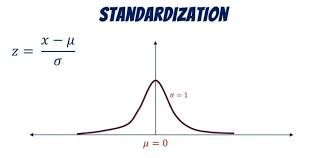


In [8]:
import csv

african_countries = ['Kenya','Uganda','Tanzania','Rwanda','Ghana','Nigeria','Mali','Burkina Faso','Benin','Togo',
    'Senegal','Sierra Leone','Liberia','Malawi','Mozambique','Zambia','Zimbabwe','Ethiopia','Egypt','Cameroon','Congo',
    'The Democratic Republic of the Congo','Somalia','South Africa','Lesotho','Namibia','Madagascar','Burundi',
    'South Sudan','Sudan','Morocco','Tunisia','Algeria',"Cote D'Ivoire",'Mauritania','Chad','Gambia','Guinea',
    'Botswana','Swaziland','Angola']

with open('kiva_loans_africa.csv', newline='', encoding='utf-8') as f_in:
    reader = csv.DictReader(f_in)
    header = reader.fieldnames
    africa_rows = [row for row in reader if row['country'] in african_countries]

with open('kiva_loans_africa.csv', 'w', newline='', encoding='utf-8') as f_out:
    writer = csv.DictWriter(f_out, fieldnames=header)
    writer.writeheader()
    writer.writerows(africa_rows)

print('African loans saved:', len(africa_rows))

African loans saved: 173038


Here i made a new dataset that has only african countries since the whole dataset was too big and had many countries.

In [9]:
import csv

FILE = "kiva_loans_africa.csv"   # the address of our file

with open(FILE, newline='', encoding='utf-8') as f:
    rows = list(csv.DictReader(f))

columns = list(rows[0].keys())
print('Number of loans (rows):', len(rows))
print('Number of original columns:', len(columns))
print('Columns:', columns)

Number of loans (rows): 173038
Number of original columns: 20
Columns: ['id', 'funded_amount', 'loan_amount', 'activity', 'sector', 'use', 'country_code', 'country', 'region', 'currency', 'partner_id', 'posted_time', 'disbursed_time', 'funded_time', 'term_in_months', 'lender_count', 'tags', 'borrower_genders', 'repayment_interval', 'date']


In [10]:
print(f"{'column':22s} {'missing':>8s}")
for col in columns:
    n_missing = sum(1 for r in rows if r[col] == '')
    print(f"{col:22s} {n_missing:8d}")

column                  missing
id                            0
funded_amount                 0
loan_amount                   0
activity                      0
sector                        0
use                        1615
country_code                  8
country                       0
region                    20615
currency                      0
partner_id                 8372
posted_time                   0
disbursed_time              381
funded_time               12193
term_in_months                0
lender_count                  0
tags                      46789
borrower_genders           1612
repayment_interval            0
date                          0


In [11]:
#  Build a table of numbers (one row per loan, one column per feature)
n = len(rows)

# --- columns that are already numbers ---
funded_amount  = np.array([float(r['funded_amount'])  for r in rows])
loan_amount    = np.array([float(r['loan_amount'])    for r in rows])
term_in_months = np.array([float(r['term_in_months']) for r in rows])
lender_count   = np.array([float(r['lender_count'])   for r in rows])

# --- dates -> days ---
def get_dates(column_name):
    # empty boxes become 'NaT' which means 'not a time'
    texts = [r[column_name][:19] if r[column_name] != '' else 'NaT' for r in rows]
    return np.array(texts, dtype='datetime64[s]')

posted    = get_dates('posted_time')
funded    = get_dates('funded_time')
disbursed = get_dates('disbursed_time')
days_to_fund     = (funded - posted)    / np.timedelta64(1, 'D')   # empty stays as nan
days_to_disburse = (disbursed - posted) / np.timedelta64(1, 'D')

# --- borrower_genders (words) -> two numbers ---
num_borrowers = np.full(n, np.nan)
female_share  = np.full(n, np.nan)
for i, r in enumerate(rows):
    g = r['borrower_genders']
    if g != '':
        people = g.split(', ')
        num_borrowers[i] = len(people)
        female_share[i]  = people.count('female') / len(people)

# --- tags (words) -> how many tags. An empty box here really means 'no tags', so it is 0 ---
num_tags = np.array([len(r['tags'].split(',')) if r['tags'] != '' else 0 for r in rows], dtype=float)

# --- repayment_interval (words) -> yes/no columns ---
interval = np.array([r['repayment_interval'] for r in rows])
is_monthly   = (interval == 'monthly').astype(float)
is_irregular = (interval == 'irregular').astype(float)
is_bullet    = (interval == 'bullet').astype(float)      # 'weekly' is the left-over case (tiny)

# --- keep sector only for colouring the plot later ---
sector = np.array([r['sector'] for r in rows])

feature_names = ['funded_amount', 'loan_amount', 'term_in_months', 'lender_count',
                 'days_to_fund', 'days_to_disburse', 'num_borrowers', 'female_share',
                 'num_tags', 'is_monthly', 'is_irregular', 'is_bullet']

X = np.column_stack([funded_amount, loan_amount, term_in_months, lender_count,
                     days_to_fund, days_to_disburse, num_borrowers, female_share,
                     num_tags, is_monthly, is_irregular, is_bullet])

print('Table shape (rows, features):', X.shape)
print(f"{'feature':18s} {'empty boxes':>12s}")
for name, count in zip(feature_names, np.isnan(X).sum(axis=0)):
    print(f'{name:18s} {count:12d}')

Table shape (rows, features): (173038, 12)
feature             empty boxes
funded_amount                 0
loan_amount                   0
term_in_months                0
lender_count                  0
days_to_fund              12193
days_to_disburse            381
num_borrowers              1612
female_share               1612
num_tags                      0
is_monthly                    0
is_irregular                  0
is_bullet                     0


In [12]:
# Fill the empty boxes with the median of each column
medians = np.nanmedian(X, axis=0)          # median of each column, ignoring empty boxes
empty_places = np.isnan(X)                 # True where a box is empty
X[empty_places] = np.take(medians, np.where(empty_places)[1])   # put the right median in each empty box

print('Empty boxes left:', np.isnan(X).sum())
print('Medians we used:')
for name, m in zip(feature_names, medians):
    print(f'  {name:18s} {m:.2f}')

Empty boxes left: 0
Medians we used:
  funded_amount      400.00
  loan_amount        425.00
  term_in_months     11.00
  lender_count       12.00
  days_to_fund       10.63
  days_to_disburse   -10.07
  num_borrowers      1.00
  female_share       1.00
  num_tags           2.00
  is_monthly         1.00
  is_irregular       0.00
  is_bullet          0.00


In [13]:
# Step 1: Standardize the data  ->  z = (x - mean) / std
mean = np.mean(X, axis=0)     # average of each column
std  = np.std(X, axis=0)      # spread of each column
Z = (X - mean) / std          # the standardized data

print('Mean of each column (should be about 0):')
print(np.mean(Z, axis=0))
print('Std of each column (should be 1):')
print(np.std(Z, axis=0))

Mean of each column (should be about 0):
[-0.  0.  0. -0.  0. -0.  0. -0.  0.  0.  0. -0.]
Std of each column (should be 1):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


### Step 3: Calculate the Covariance Matrix
The covariance matrix helps us understand how the features are related to each other. It is a key component in PCA.

In [14]:
# Step 3: Calculate the Covariance Matrix
n_rows = Z.shape[0]
cov_matrix = (Z.T @ Z) / (n_rows - 1)   # Z.T is Z flipped on its side, @ means matrix multiply

print('Shape:', cov_matrix.shape)
print('Same answer as numpy\'s own np.cov?', np.allclose(cov_matrix, np.cov(Z, rowvar=False)))
cov_matrix

Shape: (12, 12)
Same answer as numpy's own np.cov? True


array([[ 1.    ,  0.9734, -0.0411,  0.8959,  0.0436, -0.0662,  0.5235,
         0.0132,  0.3973, -0.0445,  0.0574, -0.0101],
       [ 0.9734,  1.    , -0.0338,  0.869 ,  0.0327, -0.0678,  0.5224,
        -0.0045,  0.4034, -0.0403,  0.0485, -0.0038],
       [-0.0411, -0.0338,  1.    ,  0.0054, -0.0717, -0.0081, -0.1835,
        -0.1733,  0.1057,  0.0709, -0.1409,  0.0986],
       [ 0.8959,  0.869 ,  0.0054,  1.    ,  0.077 , -0.0197,  0.3779,
         0.0057,  0.4233, -0.0192,  0.02  ,  0.002 ],
       [ 0.0436,  0.0327, -0.0717,  0.077 ,  1.    ,  0.558 ,  0.0178,
        -0.0309,  0.0928,  0.0987, -0.1278,  0.0262],
       [-0.0662, -0.0678, -0.0081, -0.0197,  0.558 ,  1.    , -0.0359,
         0.0016, -0.0191, -0.0794, -0.0939,  0.2231],
       [ 0.5235,  0.5224, -0.1835,  0.3779,  0.0178, -0.0359,  1.    ,
         0.0589,  0.2707, -0.1935,  0.0513,  0.2073],
       [ 0.0132, -0.0045, -0.1733,  0.0057, -0.0309,  0.0016,  0.0589,
         1.    , -0.066 , -0.0528,  0.2504, -0.2652],


We compute the covariance of a matrix for two reasons. First, it helps us know the features that relate to each other, in our case here, the funded_amount and loan_amount relate alot that they have a covariance of 0.97.Second, it helps get the eigen vectors and eigen values.eigenvectors point along the directions of maximum variance, and its eigenvalues measure how much variance lies along each, which is the entire basis for ranking and selecting components.

### Step 4: Perform Eigendecomposition
Eigendecomposition of the covariance matrix will give us the eigenvalues and eigenvectors, which are essential for PCA.
Fill in the code to compute the eigenvalues and eigenvectors of the covariance matrix.

In [15]:
# Step 4: Perform Eigendecomposition
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

print("Eigenvalues:", np.round(eigenvalues, 4))
print("Eigenvectors shape:", eigenvectors.shape)

Eigenvalues: [3.409  1.9354 1.6787 1.4407 1.0016 0.8015 0.6778 0.5351 0.3647 0.1261
 0.024  0.0057]
Eigenvectors shape: (12, 12)


### Step 5: Sort Principal Components
Sort the eigenvectors based on their corresponding eigenvalues in descending order. The higher the eigenvalue, the more important the eigenvector.
Complete the code to sort the eigenvectors and print the sorted components.

<a url ='https://www.youtube.com/watch?v=vaF-1xUEXsA&t=17s'>How Is Explained Variance Used In PCA?'<a/>

In [16]:
# Step 5: Sort Principal Components in descending order
sorted_indices    = np.argsort(eigenvalues)[::-1]
sorted_eigenvalues  = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices]

# Calculate explained variance ratio for each component
explained_variance_ratio = sorted_eigenvalues / np.sum(sorted_eigenvalues)
cumulative_variance      = np.cumsum(explained_variance_ratio)

print("Sorted Eigenvalues:", np.round(sorted_eigenvalues, 4))
print()
for i in range(len(sorted_eigenvalues)):
    print(f"PC{i+1}: {explained_variance_ratio[i]*100:.2f}%  |  Cumulative: {cumulative_variance[i]*100:.2f}%")

print("\nHow is explained variance used in PCA?")
print("Explained variance tells us how much information (variance) each principal component")
print("preserves from the original dataset. It helps us decide how many components to keep")
print("by selecting components that collectively retain a target percentage (e.g., 85-95%).")

Sorted Eigenvalues: [3.409  1.9354 1.6787 1.4407 1.0016 0.8015 0.6778 0.5351 0.3647 0.1261
 0.024  0.0057]

PC1: 28.41%  |  Cumulative: 28.41%
PC2: 16.13%  |  Cumulative: 44.54%
PC3: 13.99%  |  Cumulative: 58.52%
PC4: 12.01%  |  Cumulative: 70.53%
PC5: 8.35%  |  Cumulative: 78.88%
PC6: 6.68%  |  Cumulative: 85.56%
PC7: 5.65%  |  Cumulative: 91.20%
PC8: 4.46%  |  Cumulative: 95.66%
PC9: 3.04%  |  Cumulative: 98.70%
PC10: 1.05%  |  Cumulative: 99.75%
PC11: 0.20%  |  Cumulative: 99.95%
PC12: 0.05%  |  Cumulative: 100.00%

How is explained variance used in PCA?
Explained variance tells us how much information (variance) each principal component
preserves from the original dataset. It helps us decide how many components to keep
by selecting components that collectively retain a target percentage (e.g., 85-95%).


In [17]:
# Explained variance: the size of each slice of the pie, in percent
explained_variance = sorted_eigenvalues / np.sum(sorted_eigenvalues) * 100
cumulative_variance = np.cumsum(explained_variance)

print(f"{'PC':>4s} {'explained %':>12s} {'cumulative %':>13s}")
for i in range(len(explained_variance)):
    print(f'PC{i+1:<2d} {explained_variance[i]:12.2f} {cumulative_variance[i]:13.2f}')

# Dynamic choice: the smallest number of components that reaches 90%
target = 90
num_components = int(np.argmax(cumulative_variance >= target) + 1)
print(f'\nTo keep at least {target}% of the information we need {num_components} components (out of {len(explained_variance)}).')
print(f'Information we throw away: {100 - cumulative_variance[num_components-1]:.2f}%')

  PC  explained %  cumulative %
PC1         28.41         28.41
PC2         16.13         44.54
PC3         13.99         58.52
PC4         12.01         70.53
PC5          8.35         78.88
PC6          6.68         85.56
PC7          5.65         91.20
PC8          4.46         95.66
PC9          3.04         98.70
PC10         1.05         99.75
PC11         0.20         99.95
PC12         0.05        100.00

To keep at least 90% of the information we need 7 components (out of 12).
Information we throw away: 8.80%


### Step 6: Project Data onto Principal Components
Now that we’ve selected the number of components, we will project the original data onto the chosen principal components.
Fill in the code to perform the projection.

In [18]:
# Step 6: Project Data onto Principal Components
# num_components was chosen by the code in Task 2 (not guessed)
reduced_data = Z @ sorted_eigenvectors[:, :num_components]   # keep only the first num_components directions
print('Original shape:', Z.shape, '->  reduced shape:', reduced_data.shape)
reduced_data[:5]

Original shape: (173038, 12) ->  reduced shape: (173038, 7)


array([[-0.9417,  1.5923, -1.3011, -1.7382,  0.1219,  0.5213, -0.1674],
       [-0.8477,  2.114 ,  0.1091,  0.3088,  0.5593, -0.1309, -0.1891],
       [ 3.6704, -1.8796,  0.8519, -0.0738,  0.2836,  1.0079,  1.2281],
       [-1.222 , -0.1649,  1.4051, -0.0096, -0.3101, -0.38  , -1.0411],
       [-0.9043,  2.0765,  0.1172,  0.3432,  0.6418, -0.1648, -0.1748]])

### Step 7: Output the Reduced Data
Finally, display the reduced data obtained by projecting the original dataset onto the selected principal components.

In [19]:
# Step 7: Output the Reduced Data
print(f'Reduced Data Shape: {reduced_data.shape}')  # Display reduced data shape
reduced_data[:5]  # Display the first few rows of reduced data

Reduced Data Shape: (173038, 7)


array([[-0.9417,  1.5923, -1.3011, -1.7382,  0.1219,  0.5213, -0.1674],
       [-0.8477,  2.114 ,  0.1091,  0.3088,  0.5593, -0.1309, -0.1891],
       [ 3.6704, -1.8796,  0.8519, -0.0738,  0.2836,  1.0079,  1.2281],
       [-1.222 , -0.1649,  1.4051, -0.0096, -0.3101, -0.38  , -1.0411],
       [-0.9043,  2.0765,  0.1172,  0.3432,  0.6418, -0.1648, -0.1748]])

### Step 8: Visualize Before and After PCA
Now, let's plot the original data and the data after PCA to compare the reduction in dimensions visually.

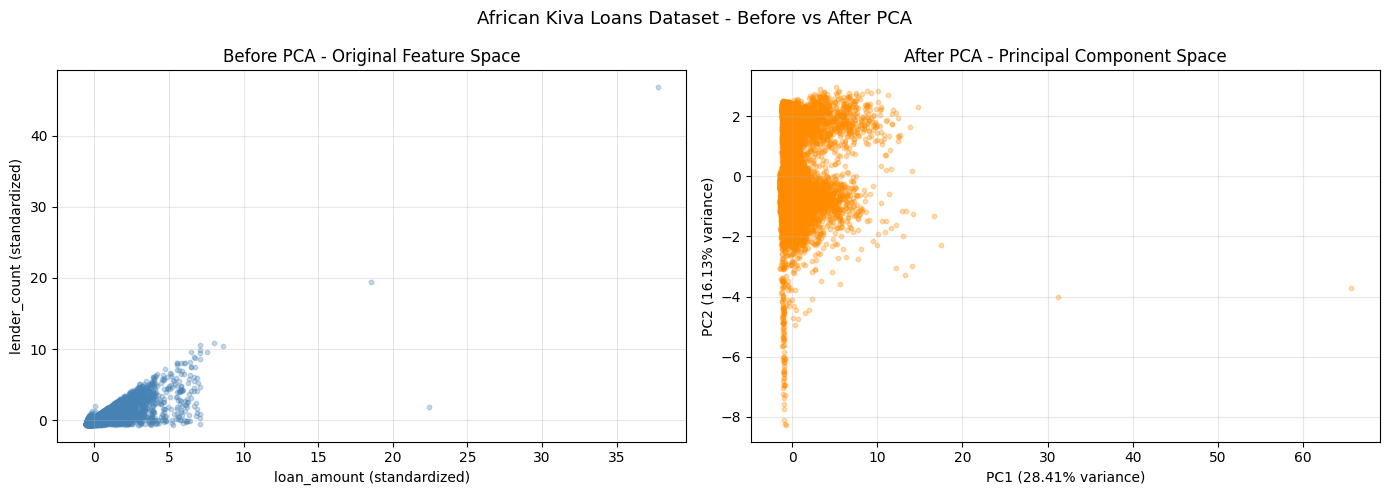

Variance of each PC (PC1 should be the biggest): [3.409  1.9353 1.6787 1.4407 1.0016 0.8015 0.6778]
Mean of each PC (should be about 0): [ 0. -0. -0. -0.  0.  0.  0.]
Points before: 173038  points after: 173038


In [20]:
# Step 8: Visualize Before and After PCA
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pick the same 20,000 random loans for both plots (173,000 dots would be one big blob)
rng = np.random.default_rng(0)
pick = rng.choice(len(Z), size=20000, replace=False)

# Which columns of Z are loan_amount and lender_count?
i_x = feature_names.index('loan_amount')
i_y = feature_names.index('lender_count')

# --- Plot 1: Before PCA ---
axes[0].scatter(Z[pick, i_x], Z[pick, i_y],
                alpha=0.3, color='steelblue', s=10)
axes[0].set_xlabel('loan_amount (standardized)')
axes[0].set_ylabel('lender_count (standardized)')
axes[0].set_title('Before PCA - Original Feature Space')
axes[0].grid(True, alpha=0.3)

# --- Plot 2: After PCA (PC1 vs PC2) ---
axes[1].scatter(reduced_data[pick, 0], reduced_data[pick, 1],
                alpha=0.3, color='darkorange', s=10)
axes[1].set_xlabel(f'PC1 ({explained_variance_ratio[0]*100:.2f}% variance)')
axes[1].set_ylabel(f'PC2 ({explained_variance_ratio[1]*100:.2f}% variance)')
axes[1].set_title('After PCA - Principal Component Space')
axes[1].grid(True, alpha=0.3)

plt.suptitle('African Kiva Loans Dataset - Before vs After PCA', fontsize=13)
plt.tight_layout()
plt.show()

print('Variance of each PC (PC1 should be the biggest):', np.var(reduced_data, axis=0))
print('Mean of each PC (should be about 0):', np.mean(reduced_data, axis=0))
print('Points before:', len(Z), ' points after:', len(reduced_data))

Please make sure you do not use more than 5 lines to answer each of the following points:

1. Interpret the Visual you just created of the before and after PCA

Before PCA, the data is shown using the original features and most points are crowded together, with a few large outliers.
After PCA, the data is transformed into new directions called principal components.
PC1 spreads the data the most, while PC2 captures the next largest variation.
The same 173,038 observations are still present, but represented in a simpler form.

2. Explain why you selected the number of principle components, more especially explain what tradeoffs you are making

I selected 7 principal components because they preserve most of the important variation in the original 12 features while reducing the dimensionality. This makes the dataset simpler to work with while keeping more information than using only 2 components. The tradeoff is that some information from the remaining 5 dimensions is lost. PC1 and PC2 are only used in the graph for visualization.

3. Clearly mention based on your use case/ dataset ("economic activity”, “population pressure”), What information is lost when reducing dimensions?

Reducing the data from 12 features to 7 principal components means some information from the original features is lost. Smaller patterns in loan amount, lender count, and other Kiva loan features may not be fully preserved. Also, the principal components combine several original features, so they are harder to interpret directly. However, the most important variation in the data is still retained.
